In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import RMSprop
import matplotlib.pyplot as plt
import pandas as pd

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0

def create_model(lr):
    m = Sequential([
        Dense(128, activation='relu', input_shape=(784,)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    m.compile(
        optimizer=RMSprop(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return m


   Learning Rate  Accuracy
0         0.0500    0.8967
1         0.0050    0.9726
2         0.0005    0.9729


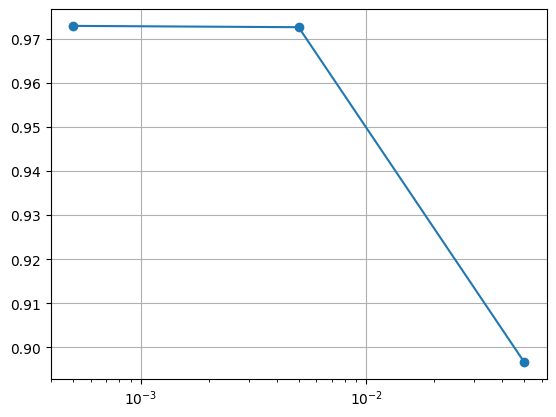

In [ ]:
learning_rates=[0.05, 0.005, 0.0005]
results=[]
for lr in learning_rates:
    model=create_model(lr)
    model.fit(x_train,y_train,epochs=5,batch_size=64,verbose=0)
    loss,acc=model.evaluate(x_test,y_test,verbose=0)
    results.append([lr,acc])
df=pd.DataFrame(results,columns=['Learning Rate','Accuracy'])
print(df)
plt.plot(df['Learning Rate'],df['Accuracy'],marker='o')
plt.xscale('log'); plt.grid(); plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Epochs  Accuracy
0      10    0.9762
1      20    0.9803
2      30    0.9806


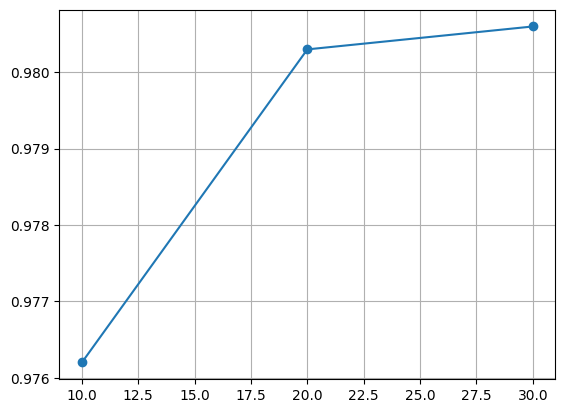

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8995 - loss: 0.3606 - val_accuracy: 0.9432 - val_loss: 0.1924
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9537 - loss: 0.1572 - val_accuracy: 0.9595 - val_loss: 0.1387
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9667 - loss: 0.1100 - val_accuracy: 0.9668 - val_loss: 0.1129
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9735 - loss: 0.0844 - val_accuracy: 0.9697 - val_loss: 0.1022
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9797 - loss: 0.0664 - val_accuracy: 0.9710 - val_loss: 0.0993
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9834 - loss: 0.0531 - val_accuracy: 0.9726 - val_loss: 0.0946
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9869 - loss: 0.0429 - val_accuracy: 0.9707 - val_loss: 0.0997
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9889 - loss: 0.0357 - val_accuracy: 0.

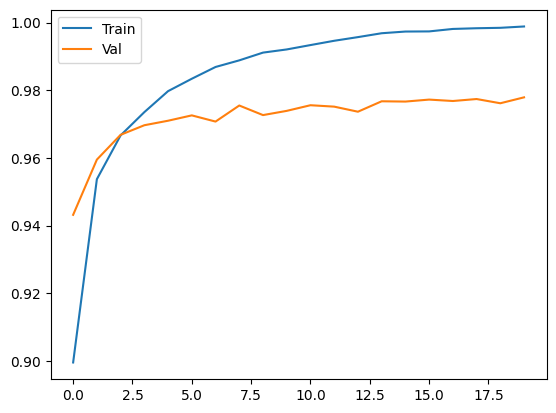

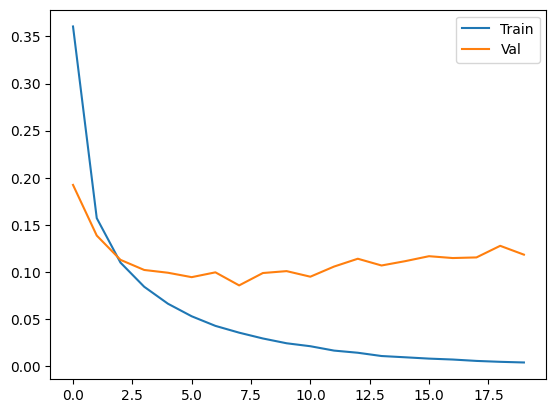

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9769 - loss: 0.1106
[0.11057541519403458, 0.9768999814987183]


In [ ]:
epochs_list=[10, 20, 30]
res=[]
for ep in epochs_list:
    model=create_model(0.001)
    h=model.fit(x_train,y_train,validation_split=0.2,epochs=ep,batch_size=128,verbose=0)
    loss,acc=model.evaluate(x_test,y_test,verbose=0)
    res.append([ep,acc])
edf=pd.DataFrame(res,columns=['Epochs','Accuracy'])
print(edf)
plt.plot(edf['Epochs'],edf['Accuracy'],marker='o')
plt.grid(); plt.show()

model=create_model(0.001)
history=model.fit(x_train,y_train,validation_split=0.2,epochs=20,batch_size=128)
plt.plot(history.history['accuracy']); plt.plot(history.history['val_accuracy']); plt.legend(['Train','Val']); plt.show()
plt.plot(history.history['loss']); plt.plot(history.history['val_loss']); plt.legend(['Train','Val']); plt.show()
print(model.evaluate(x_test,y_test))
